<a href="https://colab.research.google.com/github/MrCherveN/Machine-Learning--4-0_HomeTasks/blob/main/HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
!pip install opendatasets --upgrade --quiet

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any
import opendatasets as od
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [3]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4'
od.download(dataset_url)
data_dir = '/content/bank-customer-churn-prediction-dlu-course-c-4'
train_csv = data_dir + '/train.csv'

raw_df = pd.read_csv(train_csv)

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-4" (use force=True to force download)


In [4]:
raw_df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [5]:
target_col = 'Exited'
input_cols = [col for col in raw_df.columns if col not in [target_col, 'id', 'CustomerId', 'Surname']]

In [6]:
train_df, val_df = split_train_val(raw_df, target_col)

In [7]:
train_df.shape, val_df.shape

((12000, 14), (3000, 14))

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               12000 non-null  int64  
 1   CustomerId       12000 non-null  float64
 2   Surname          12000 non-null  object 
 3   CreditScore      12000 non-null  float64
 4   Geography        12000 non-null  object 
 5   Gender           12000 non-null  object 
 6   Age              12000 non-null  float64
 7   Tenure           12000 non-null  float64
 8   Balance          12000 non-null  float64
 9   NumOfProducts    12000 non-null  float64
 10  HasCrCard        12000 non-null  float64
 11  IsActiveMember   12000 non-null  float64
 12  EstimatedSalary  12000 non-null  float64
 13  Exited           12000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.4+ MB


In [9]:
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

In [10]:
train_inputs.shape, val_inputs.shape

((12000, 10), (3000, 10))

In [11]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      12000 non-null  float64
 1   Geography        12000 non-null  object 
 2   Gender           12000 non-null  object 
 3   Age              12000 non-null  float64
 4   Tenure           12000 non-null  float64
 5   Balance          12000 non-null  float64
 6   NumOfProducts    12000 non-null  float64
 7   HasCrCard        12000 non-null  float64
 8   IsActiveMember   12000 non-null  float64
 9   EstimatedSalary  12000 non-null  float64
dtypes: float64(8), object(2)
memory usage: 1.0+ MB


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [12]:
cat_col = train_inputs.select_dtypes('object').columns

for col_name in cat_col:
  train_inputs[col_name] = train_inputs[col_name].astype('category')
  val_inputs[col_name] = val_inputs[col_name].astype('category')

In [13]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      12000 non-null  float64 
 1   Geography        12000 non-null  category
 2   Gender           12000 non-null  category
 3   Age              12000 non-null  float64 
 4   Tenure           12000 non-null  float64 
 5   Balance          12000 non-null  float64 
 6   NumOfProducts    12000 non-null  float64 
 7   HasCrCard        12000 non-null  float64 
 8   IsActiveMember   12000 non-null  float64 
 9   EstimatedSalary  12000 non-null  float64 
dtypes: category(2), float64(8)
memory usage: 867.4 KB


In [14]:
val_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 6490 to 3024
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      3000 non-null   float64 
 1   Geography        3000 non-null   category
 2   Gender           3000 non-null   category
 3   Age              3000 non-null   float64 
 4   Tenure           3000 non-null   float64 
 5   Balance          3000 non-null   float64 
 6   NumOfProducts    3000 non-null   float64 
 7   HasCrCard        3000 non-null   float64 
 8   IsActiveMember   3000 non-null   float64 
 9   EstimatedSalary  3000 non-null   float64 
dtypes: category(2), float64(8)
memory usage: 217.0 KB


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [15]:
def evaluate_model(inputs, targets, model, name=''):
  preds = model.predict(inputs)
  f1_score_ = f1_score(targets, preds, pos_label=1)
  print(f"\nF1 score {name}: {f1_score_:.4f}")

  probs = model.predict_proba(inputs)[:, 1]
  auc = roc_auc_score(targets, probs)
  print(f'AUROC for {name}: {auc:.4f}')

  cf = confusion_matrix(targets, preds, normalize='true')
  print(f'Confusion Matrix (normalized):\n {np.round(cf, 4)}\n')

In [16]:
#!conda install -c conda-forge xgboost

In [17]:
from xgboost import XGBClassifier

In [18]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,  # для категорійних ознак
    #use_label_encoder=False,  # щоб уникнути попереджень, якщо використовуєте нові версії XGBoost
    missing=np.nan,  # явне вказування пропущених значень
    device='cuda',
    random_state=42
)

xgb_clf.fit(train_inputs, train_targets)

evaluate_model(train_inputs, train_targets, xgb_clf, 'Training')
evaluate_model(val_inputs, val_targets, xgb_clf, 'Validation')



F1 score Training: 0.7242
AUROC for Training: 0.9330
Confusion Matrix (normalized):
 [[0.9639 0.0361]
 [0.3522 0.6478]]


F1 score Validation: 0.7118
AUROC for Validation: 0.9326
Confusion Matrix (normalized):
 [[0.9569 0.0431]
 [0.3541 0.6459]]



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:17:21] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:17:21] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


***Висновок:***
- Отримана модель виявилася хорошою, high bias та high variance відсутні.
- В завданні побудови моделі дерева прийняття рішень я отримав наступні результати:

        - max_depth: 5
        - AUROC for Training: 0.93
        - AUROC for Validation: 0.92

Як бачимо, отримані результати за XGBoost є кращими.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [19]:
!pip install hyperopt

In [20]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from numpy.random import default_rng

In [21]:
RANDOM_STATE = 42

def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        #use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        random_state=RANDOM_STATE,
        early_stopping_rounds=10,

    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)

    probs = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, probs)

    return {'loss': -auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials, rstate=default_rng(RANDOM_STATE))

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    #use_label_encoder=False,
    missing=np.nan,
    device='cuda',
    random_state=RANDOM_STATE,
    early_stopping_rounds=10,

)

final_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)], verbose=False)

evaluate_model(train_inputs, train_targets, final_clf, 'Training')
evaluate_model(val_inputs, val_targets, final_clf, 'Validation')

  5%|▌         | 1/20 [00:00<00:03,  5.52trial/s, best loss: -0.9359702311544001]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:17:35] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:17:35] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:17:35] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:17:35] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_roun

 10%|█         | 2/20 [00:00<00:03,  4.97trial/s, best loss: -0.9365031895191714]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:17:35] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:17:35] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()



 15%|█▌        | 3/20 [00:01<00:08,  2.09trial/s, best loss: -0.9365031895191714]

...

 95%|█████████▌| 19/20 [00:25<00:01,  1.52s/trial, best loss: -0.9366722683311612]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:18:00] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:18:00] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:25<00:00,  1.30s/trial, best loss: -0.9366722683311612]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.5791069510022959), 'gamma': np.float64(0.46622574683653734), 'learning_rate': np.float64(0.18845623496792444), 'max_depth': 4, 'min_child_weight': 9, 'n_estimators': 200, 'reg_alpha': np.float64(0.2042842520101622), 'reg_lambda': np.float64(0.9877372119600353), 'subsample': np.float64(0.9376238045745737)}


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:18:01] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:18:01] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()



F1 score Training: 0.7649
AUROC for Training: 0.9482
Confusion Matrix (normalized):
 [[0.9656 0.0344]
 [0.2973 0.7027]]


F1 score Validation: 0.7389
AUROC for Validation: 0.9367
Confusion Matrix (normalized):
 [[0.9582 0.0418]
 [0.318  0.682 ]]



***Висновок:***
- Використання бібліотеки Hyperopt для автоматизованого підбору гіперпараметрів дозволило покращити якість моделі порівняно з попереднім пунктом (2) цього завдання.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [22]:
# %%bash
# sudo apt-get update
# sudo apt-get install -y build-essential cmake git wget unzip
# sudo apt-get install -y libboost-dev libboost-system-dev libboost-filesystem-dev
# sudo apt-get install -y libboost-iostreams-dev libboost-program-options-dev libboost-regex-dev
# sudo apt-get install -y libboost-thread-dev libboost-chrono-dev libboost-date-time-dev
# sudo apt-get install -y libboost-atomic-dev libboost-serialization-dev
# sudo apt-get install -y python3-pip
# sudo apt-get install -y ocl-icd-libopencl1 clinfo
# sudo apt-get install -y nvidia-opencl-dev opencl-headers
# git clone --recursive https://github.com/microsoft/LightGBM
# cd LightGBM
# mkdir build
# cd build
# cmake -DUSE_CUDAP=1 ..
# make -j4

In [23]:
# %%bash
# cd ..
# python setup.py install

In [24]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      12000 non-null  float64 
 1   Geography        12000 non-null  category
 2   Gender           12000 non-null  category
 3   Age              12000 non-null  float64 
 4   Tenure           12000 non-null  float64 
 5   Balance          12000 non-null  float64 
 6   NumOfProducts    12000 non-null  float64 
 7   HasCrCard        12000 non-null  float64 
 8   IsActiveMember   12000 non-null  float64 
 9   EstimatedSalary  12000 non-null  float64 
dtypes: category(2), float64(8)
memory usage: 867.4 KB


In [25]:
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_col]
cat_col, cat_feature_indexes

(Index(['Geography', 'Gender'], dtype='object'), [1, 2])

In [26]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [27]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=8,
    n_estimators=100,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень
    #device='cuda'  # використовувати GPU для прискорення обчислень
    random_state=RANDOM_STATE,
    verbose=-1,
)

lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])


evaluate_model(train_inputs, train_targets, lgb_clf, 'Training')
evaluate_model(val_inputs, val_targets, lgb_clf, 'Validation')


F1 score Training: 0.8183
AUROC for Training: 0.9733
Confusion Matrix (normalized):
 [[0.9724 0.0276]
 [0.2326 0.7674]]


F1 score Validation: 0.7350
AUROC for Validation: 0.9324
Confusion Matrix (normalized):
 [[0.9506 0.0494]
 [0.3066 0.6934]]



***Висновок:***
- Хоч отримана модель і показує високі значення на тренувальних даних та валідаційних даних, але відмінність між ними в більше ніж 4% свідчить про наявність high variance. Потрібно застосовувати механізми тюнінгу гіперпараметрів.
- В порівнянні з результатами з XGBoostClassifier отримав гірші результати на валідаційних даних.

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [28]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        random_state=RANDOM_STATE,
        early_stopping_round=10,
        verbose=-1,
    )

    clf.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)])

    probs = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, probs)

    return {'loss': -auc, 'status': STATUS_OK}


# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials, rstate=default_rng(RANDOM_STATE))

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    missing=np.nan,
    random_state=RANDOM_STATE,
    early_stopping_round=10,
    verbose=-1,
)

final_lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

evaluate_model(train_inputs, train_targets, final_lgb_clf, 'Training')
evaluate_model(val_inputs, val_targets, final_lgb_clf, 'Validation')

100%|██████████| 10/10 [00:01<00:00,  5.44trial/s, best loss: -0.9367905892036492]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.6043143849848778), 'learning_rate': np.float64(0.10914306477998553), 'max_depth': 3, 'min_child_weight': 9, 'min_split_gain': np.float64(0.007898327983574649), 'n_estimators': 300, 'num_leaves': 28, 'reg_alpha': np.float64(0.8609304819134347), 'reg_lambda': np.float64(0.6082491621711366), 'subsample': np.float64(0.6502106773952542)}

F1 score Training: 0.7550
AUROC for Training: 0.9430
Confusion Matrix (normalized):
 [[0.9639 0.0361]
 [0.3079 0.6921]]


F1 score Validation: 0.7353
AUROC for Validation: 0.9368
Confusion Matrix (normalized):
 [[0.9573 0.0427]
 [0.3213 0.6787]]



***Висновок:***
- Побудована модель показала значно кращі результати, ніж модель в п.4 цього ДЗ(збільшилося значення AUROC на валідаційних даних та зменшилося значення Variance).

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [29]:
test_raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/test.csv')

In [30]:
test_inputs = test_raw_df[input_cols].copy()

for col_name in cat_col:
  test_inputs[col_name] = test_inputs[col_name].astype('category')

test_inputs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  float64 
 1   Geography        10000 non-null  category
 2   Gender           10000 non-null  category
 3   Age              10000 non-null  float64 
 4   Tenure           10000 non-null  float64 
 5   Balance          10000 non-null  float64 
 6   NumOfProducts    10000 non-null  float64 
 7   HasCrCard        10000 non-null  float64 
 8   IsActiveMember   10000 non-null  float64 
 9   EstimatedSalary  10000 non-null  float64 
dtypes: category(2), float64(8)
memory usage: 644.9 KB


In [31]:
test_preds = final_lgb_clf.predict(test_inputs)
test_proba = final_lgb_clf.predict_proba(test_inputs)[:, 1]

test_raw_df['Exited'] = test_proba
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.095178
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.014380
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.062695
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.498755
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.031365


In [32]:
submission_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv')
submission_df.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [33]:
submission_df['Exited'] = test_raw_df['Exited']
submission_df.head()

,id,Exited
0,15000,0.095178
1,15001,0.014380
2,15002,0.062695
3,15003,0.498755
4,15004,0.031365


In [34]:
submission_df.to_csv('submission_log_reg.csv', index=False)

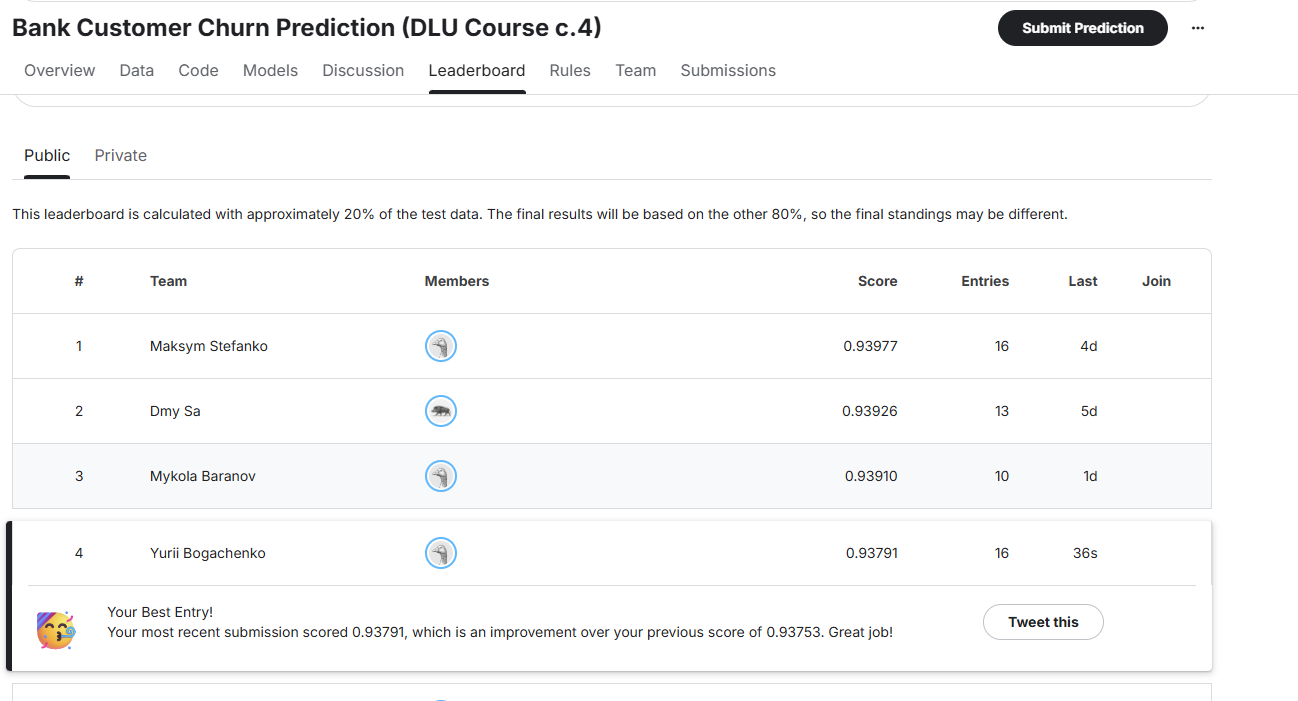

Обрав модель LightGBM, оскільки вона в порівнянні з XGBoost є стабільнішою - різниця по AUROC  між навчальними та валідаційними даними складає менше 1% .